
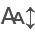

In [1]:
import torch
import torch.optim as optim
from torchviz import make_dot
import pandas as pd
from itables import init_notebook_mode, show
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import importlib
from tqdm import tqdm
from torchvision import transforms

import gradual_aacbr
import semantics.mlp_semantics as ms
import base_scores.feature_weighted_base_score as fwbs
import casebase_edge_weights.feature_weighted_partial_order as fwpo
import casebase_edge_weights.learned_partial_order as lpo
import irrelevance_edge_weights.feature_weighted_irrelevance as fwi
import irrelevance_edge_weights.regular_irrelevance as ri

init_notebook_mode(all_interactive=True)

In [2]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(ms)
    importlib.reload(fwbs)
    importlib.reload(fwpo)
    importlib.reload(fwi)
    importlib.reload(ri)
    importlib.reload(lpo)

reload_imports()

## Gradual AACBR

tensor([[0.5828, 0.5846]], grad_fn=<IndexBackward0>)


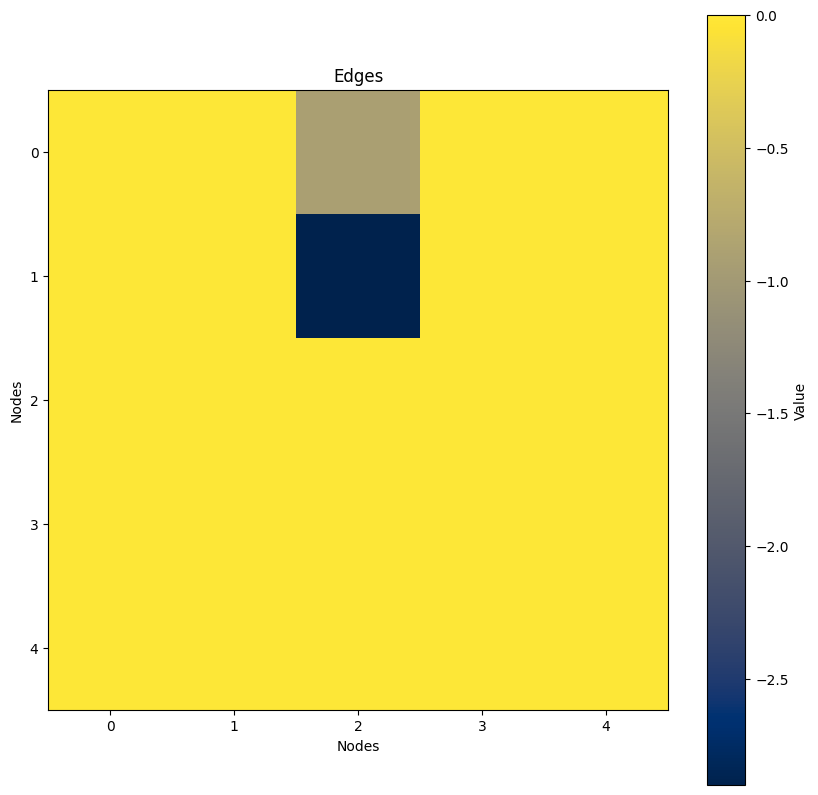

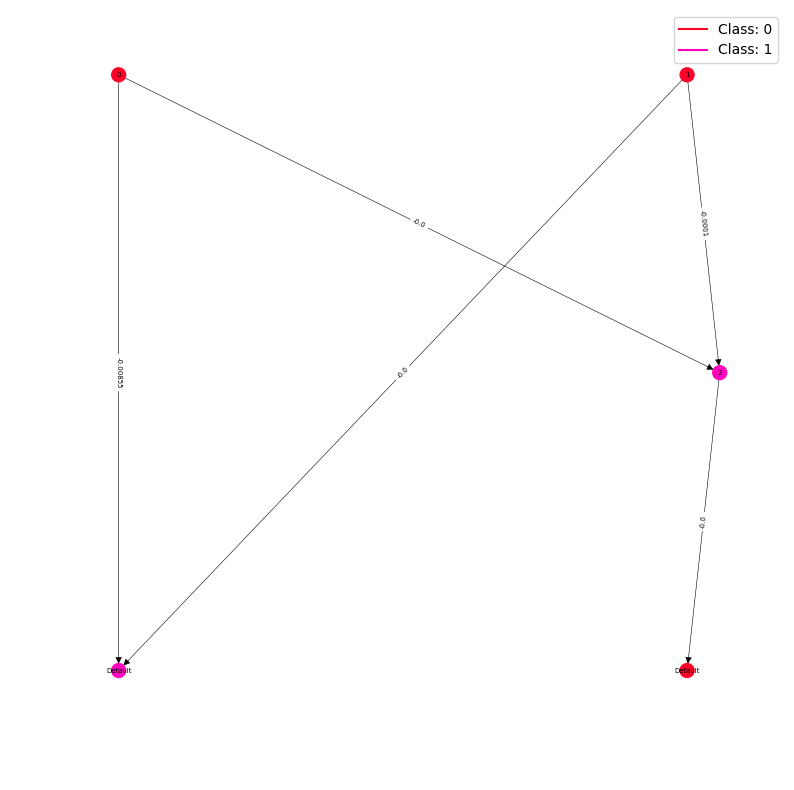

In [3]:
reload_imports()
X_train = torch.tensor([
    [1], # 0
    [3], # 1
    [5], # 1
], dtype=torch.float32)

y_train = torch.tensor([[1, 0], [1, 0], [0, 1]], dtype=torch.float32)

X_default = torch.tensor([
        [0], [0]
], dtype=torch.float32) # 2, 3
y_default = torch.tensor([[0, 1], [1, 0]], dtype=torch.float32)

torch.manual_seed(0)

no_features = X_train.shape[-1]
semantics = ms.MLPBasedSemantics(max_iters=5, epsilon=0)
model = gradual_aacbr.GradualAACBR(semantics, 
                                   fwbs.FeatureWeightedBaseScore(no_features), 
                                   fwi.FeatureWeightedIrrelevance(no_features), 
                                   fwpo.FeatureWeightedPartialOrder(no_features, sharpness=0.5))

model.fit(X_train, y_train, X_default, y_default)

new_case = torch.tensor([
    [2],
], dtype=torch.float32)

strengths = model(new_case)
print(strengths)

model.show_matrix()
model.show_graph_with_labels()



## Data Set

In [4]:
SEED = 42

In [5]:
# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 
  
# # data (as pandas dataframes) 
# X = connectionist_bench_sonar_mines_vs_rocks.data.features 
# y = connectionist_bench_sonar_mines_vs_rocks.data.targets 

data = pd.read_csv('data/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data')

data = data.values

X = np.array(data[:, :-1], dtype=np.float32)
y = np.array(data[:, -1])

show(X)
print(np.unique(y))



['M' 'R']


In [6]:
y = y.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
# encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

show(y)


## Train Model

### Split into Training, Validation and Test

In [7]:
X, y = torch.tensor(X), torch.tensor(y, dtype=torch.float32)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")

Test Size:  42
Train Size:  132
Validation Size:  33


### Normalize dataset

In [8]:
# train_mean = X_train.mean(dim=0)
# train_std = X_train.std(dim=0)

# X_train = (X_train - train_mean)/train_std
# X_val = (X_val - train_mean)/train_std
# X_test = (X_test - train_mean)/train_std



In [9]:
print(X_train)

tensor([[0.0176, 0.0172, 0.0501,  ..., 0.0179, 0.0294, 0.0063],
        [0.0195, 0.0142, 0.0181,  ..., 0.0042, 0.0067, 0.0012],
        [0.0294, 0.0123, 0.0117,  ..., 0.0006, 0.0081, 0.0043],
        ...,
        [0.0423, 0.0321, 0.0709,  ..., 0.0021, 0.0043, 0.0017],
        [0.0409, 0.0421, 0.0573,  ..., 0.0061, 0.0030, 0.0078],
        [0.0132, 0.0080, 0.0188,  ..., 0.0140, 0.0028, 0.0064]])


### Build AF

In [10]:
# TODO: Consider more sophisticated orders

# Compare against the average for each column
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

STD_PARAM = 1.5 

def binarise_by_normal(case):
    # return np.where(np.abs(case - means) <= STD_PARAM*std, 0, 1)
    return torch.where(torch.abs(case - means) <= STD_PARAM*std, 0, 1).to(torch.float32)


In [11]:
# PREPROCESS_FUNC = binarise_by_normal 
PREPROCESS_FUNC = lambda x: x

### Train Model

In [12]:
DEFAULT_CASE = means

X_DEFAULTS = DEFAULT_CASE.tile(2, 1)
Y_DEFAULTS = torch.tensor([[0, 1], [1, 0]])

MAX_ITERS = 1 
EPOCHS = 75 
N_SPLITS = 5
USE_SYMMETRIC_ATTACKS = True

In [13]:
reload_imports()

def run_gradual_model(model: gradual_aacbr.GradualAACBR, X_train, y_train, X_default, 
                      y_default, new_cases):

    model.fit(PREPROCESS_FUNC(X_train), y_train, X_default, y_default, USE_SYMMETRIC_ATTACKS)
    return model(PREPROCESS_FUNC(new_cases))


def evaluate_model(model, X_train, y_train, X_default, y_default, new_cases, new_cases_labels,
                   show_confusion=False, print_graph=False, print_matrix=False, print_compute_graph = False):


    final_strengths = run_gradual_model(model, X_train, y_train, X_default, y_default, new_cases)
    predicted = final_strengths.cpu().detach().numpy()

    predicted = np.argmax(predicted, axis=1)
    new_cases_labels_orig = np.argmax(new_cases_labels, axis=1)

    print("Accuracy, Precision, Recall, F1")
    print([
        accuracy_score(new_cases_labels_orig, predicted),
        precision_score(new_cases_labels_orig, predicted, average='macro'),
        recall_score(new_cases_labels_orig, predicted, average='macro'),
        f1_score(new_cases_labels_orig, predicted, average='macro')
    ])


    if show_confusion:
        cm = confusion_matrix(new_cases_labels_orig, predicted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()

    if print_graph:
        model.show_graph_with_labels()

    if print_matrix:
        model.show_matrix()

    if print_compute_graph:
        criterion = torch.nn.CrossEntropyLoss()
        loss = criterion(final_strengths.squeeze(), new_cases_labels)
        make_dot(loss, params=dict(model.named_parameters())).render("gradual_aacbr", format="pdf")



In [18]:
reload_imports()
torch.manual_seed(0) # TRY DIFFERENT INITIAL WEIGHTS 
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

no_features = X_train.shape[-1]
semantics = ms.MLPBasedSemantics(max_iters=MAX_ITERS, epsilon=0)
# partial_order = fwpo.FeatureWeightedPartialOrder(no_features, sharpness=100)
partial_order = lpo.LearnedPartialOrder(no_features, no_hidden=10, sharpness=0.5)
# irrelevance = ri.RegularIrrelevance(partial_order)
irrelevance = fwi.FeatureWeightedIrrelevance(no_features)
base_score = fwbs.FeatureWeightedBaseScore(no_features)

model = gradual_aacbr.GradualAACBR(semantics, 
                                base_score,
                                irrelevance,
                                partial_order)

# criterion = torch.nn.BCELoss()
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

Accuracy, Precision, Recall, F1
[0.5151515151515151, 0.25757575757575757, 0.5, 0.34]


/home/adam/.pyenv/versions/3.10.13/envs/gradual-aacbr/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


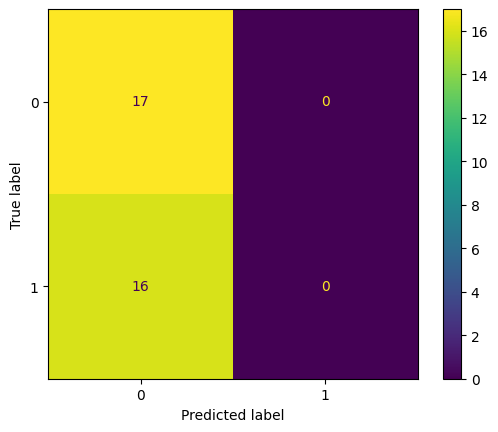

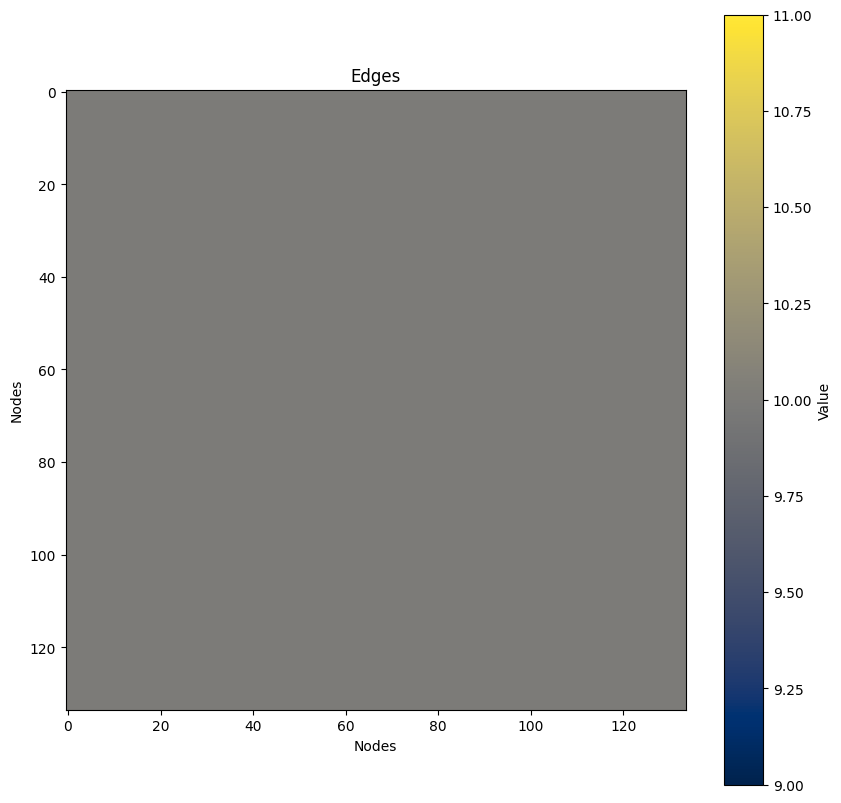

fc1.weight tensor([[-0.0007,  0.0490, -0.0751, -0.0672, -0.0352,  0.0245, -0.0018,  0.0724,
         -0.0081,  0.0242, -0.0276, -0.0179, -0.0872, -0.0605, -0.0376,  0.0034,
          0.0361,  0.0548, -0.0619, -0.0398,  0.0332,  0.0758, -0.0188,  0.0683,
         -0.0147,  0.0097,  0.0827, -0.0847, -0.0575, -0.0231, -0.0356,  0.0789,
         -0.0592, -0.0420, -0.0638, -0.0855, -0.0533,  0.0785,  0.0407,  0.0442,
          0.0048, -0.0468,  0.0154, -0.0852, -0.0660, -0.0471,  0.0576,  0.0535,
         -0.0405, -0.0033,  0.0584,  0.0908,  0.0362,  0.0123,  0.0612, -0.0538,
          0.0170, -0.0708, -0.0633, -0.0472,  0.0413,  0.0367, -0.0541,  0.0276,
          0.0501, -0.0115,  0.0035,  0.0212,  0.0566,  0.0877, -0.0703, -0.0335,
          0.0359,  0.0756,  0.0794,  0.0805,  0.0182, -0.0794,  0.0084, -0.0571,
         -0.0851,  0.0811,  0.0694, -0.0911,  0.0171, -0.0154, -0.0150, -0.0418,
          0.0351, -0.0541,  0.0335,  0.0462,  0.0653,  0.0341, -0.0904, -0.0592,
          0.0456,

In [19]:
reload_imports()
evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True,  print_matrix=True, print_compute_graph=True, print_graph = False )
show(model.A.detach().numpy())
model.plot_casebase_edge_weights_parameters()

In [20]:

DISABLE_TQDM = False

In [21]:
reload_imports()
losses = []
pbar = tqdm(range(EPOCHS), disable=DISABLE_TQDM)

for epoch in pbar:  
    for fold, (casebase_index,  new_cases_index) in enumerate(kf.split(X_train)):

        new_cases = X_train[new_cases_index]
        new_cases_labels = y_train[new_cases_index]

        casebase = X_train[casebase_index]
        casebase_labels = y_train[casebase_index]

        optimizer.zero_grad()

        # TODO: consider efficiency issues with having to rebuild each time 
        # Find a way to accumulate gradients update only when necessary?
        model.fit(casebase, casebase_labels, X_DEFAULTS, Y_DEFAULTS, USE_SYMMETRIC_ATTACKS)

        predictions = model(new_cases).squeeze()
        loss = criterion(predictions, new_cases_labels)
        loss.backward()

        optimizer.step()

        losses.append(loss.item()/len(new_cases))
        # Print gradients
        # print("Gradients for each layer:")
        # for name, param in model.named_parameters():
        #     if param.grad is not None:
        #         print(f"Layer: {name} | Gradients: {param.grad}")
        #     else:
        #         print(f"Layer: {name} | No gradients computed")


    pbar.set_description(f'Epoch {epoch + 1}, Loss: {round(loss.item()/len(new_cases), 4)}')






print('Finished Training')

plt.plot(losses)
plt.show()


Epoch 7, Loss: 0.0267:   9%|▉         | 7/75 [00:10<01:39,  1.46s/it]


KeyboardInterrupt: 

Accuracy, Precision, Recall, F1
[0.5151515151515151, 0.25757575757575757, 0.5, 0.34]


/home/adam/.pyenv/versions/3.10.13/envs/gradual-aacbr/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


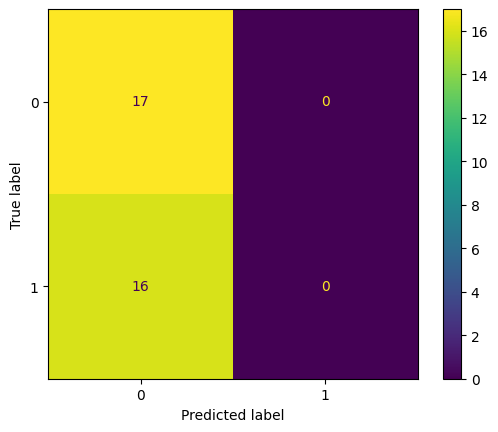

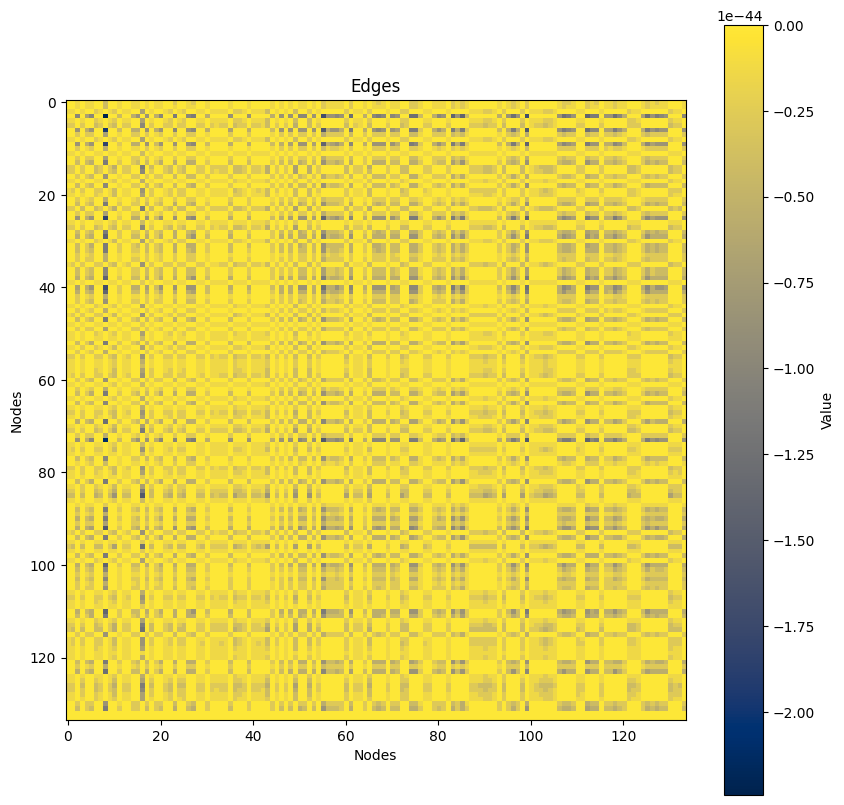

fc1.weight tensor([[-0.0007,  0.0490, -0.0751, -0.0672, -0.0352,  0.0245, -0.0018,  0.0724,
         -0.0081,  0.0242, -0.0276, -0.0179, -0.0872, -0.0605, -0.0376,  0.0034,
          0.0361,  0.0548, -0.0619, -0.0398,  0.0332,  0.0758, -0.0188,  0.0683,
         -0.0147,  0.0097,  0.0827, -0.0847, -0.0575, -0.0231, -0.0356,  0.0789,
         -0.0592, -0.0420, -0.0638, -0.0855, -0.0533,  0.0785,  0.0407,  0.0442,
          0.0048, -0.0468,  0.0154, -0.0852, -0.0660, -0.0471,  0.0576,  0.0535,
         -0.0405, -0.0033,  0.0584,  0.0908,  0.0362,  0.0123,  0.0612, -0.0538,
          0.0170, -0.0708, -0.0633, -0.0472,  0.0413,  0.0367, -0.0541,  0.0276,
          0.0501, -0.0115,  0.0035,  0.0212,  0.0566,  0.0877, -0.0703, -0.0335,
          0.0359,  0.0756,  0.0794,  0.0805,  0.0182, -0.0794,  0.0084, -0.0571,
         -0.0851,  0.0811,  0.0694, -0.0911,  0.0171, -0.0154, -0.0150, -0.0418,
          0.0351, -0.0541,  0.0335,  0.0462,  0.0653,  0.0341, -0.0904, -0.0592,
          0.0456,

In [ ]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True,  print_matrix=True, print_compute_graph=False  )

model.plot_casebase_edge_weights_parameters()

### Test Set

In [ ]:
# reload_imports()
# with torch.no_grad():
#     evaluate_model(X_train_full, y_train_full, X_test, y_test, show_confusion=True)